<a href="{{ colab_base_laboratorios }}/Laboratorio_01_pinguinos_v2.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Laboratorio 1 Santiago Angulo 1001154362

LABORATORIO — Observatorio de Datos (Pingüinos)

Objetivo
Guiar para la exploración, descripción, formulación de hipótesis y pruebas básicas usando el dataset de pingüinos, hasta generar un reporte reproducible. El laboratorio se divide en dos fases: (1) enfoque clásico con notebook y (2) enfoque con agentes.

Requisitos
- Python 3.x
- pandas, numpy, matplotlib, seaborn (opcional)
- scipy (opcional, para pruebas)

FASE 1 — Enfoque clásico (hasta Parte F)

Nota: el estudiante debe construir su propio runner (script en Python) para ejecutar operaciones y guardar artifacts.

Parte A — Observación inicial
1) ¿Cuántas filas y columnas tiene el dataset?
2) ¿Qué variables son numéricas y cuáles categóricas?
3) ¿Cuántos valores faltantes hay por columna?
4) ¿Existen filas duplicadas?
5) ¿Qué variables tienen baja cardinalidad?

Parte B — Descripción
6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
7) Para cada variable categórica, reporte conteos y porcentajes.
8) Construya tablas cruzadas para pares de variables categóricas relevantes.
9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

Parte C — Visualización
10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
11) Genere histogramas para variables numéricas y describa su forma.
12) Genere boxplots de una variable numérica por categoría (p. ej., `bill_length_mm` por `species`).
13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
14) Genere un heatmap de correlación.

Parte D — Hipótesis (sin causalidad)
15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.
   Ejemplos:
   - `flipper_length_mm` se asocia con `body_mass_g`.
   - `bill_length_mm` difiere por `species`.
   - `species` se asocia con `island`.

Parte E — Pruebas estadísticas
16) Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado).
17) Reporte estadístico y p-valor.
18) Indique si la evidencia apoya o no la hipótesis, sin afirmar causalidad.

Parte F — Conclusiones y reporte
19) Redacte conclusiones en tres capas:
    A) Hallazgos descriptivos (con evidencia).
    B) Patrones visuales (con evidencia).
    C) Próximas hipótesis a probar.
20) Incluya preguntas para un investigador humano (p. ej., manejo de la variable `sex`, control por `species`).

Parte G — Ejecución del pipeline (opcional)
21) Ejecute el flujo automático:
    - python pipeline.py
22) Revise el HTML final en artifacts/observatorio.html.


FASE 2 — Enfoque con Agentes (Generalización)

En esta fase se introduce una arquitectura basada en la separación entre Agente y Runner. La idea central es simple: el agente planifica e interpreta, el runner ejecuta y calcula. El agente propone qué operaciones realizar y redacta conclusiones, pero no hace cálculos. El runner ejecuta código en Python, calcula estadísticas, genera gráficos y escribe artifacts (archivos JSON/PNG).

Esta separación mejora la reproducibilidad y reduce errores conceptuales: el agente solo puede usar la evidencia contenida en artifacts. No puede inventar valores ni asumir resultados.

El estudiante debe construir su propio runner y conectarlo con las recomendaciones del agente.

---

Preparación del agente

Primero se crea una carpeta independiente para este enfoque. Allí se copia el archivo de guía del agente (por ejemplo, Promts/hola_agentes.txt) y se adapta si es necesario. En cada interacción debe definirse claramente la fase actual (OBSERVE, DESCRIBE o HYPOTHESIZE_AND_CONCLUDE) y qué artifacts están disponibles.

---

Algoritmo general del enfoque con agentes

Antes de usar el agente, se debe tener claro qué es cada componente:

* Runner: script en Python que calcula, genera gráficos y escribe artifacts.
* Artifacts: archivos JSON o PNG que contienen resultados verificables. Son la única fuente válida de evidencia.
* Agente: propone acciones y redacta hipótesis o conclusiones con base en artifacts.

El proceso comienza preparando el runner. Se crea un archivo runner.py con funciones básicas de observación: perfil del dataset, inferencia de esquema, reporte de faltantes y duplicados. Se agrega la carga del dataset (por ejemplo, seaborn o CSV remoto) y la creación automática de la carpeta artifacts. El runner debe poder ejecutar la fase OBSERVE y generar artifacts/00_raw_profile.json.

Luego se inicia la interacción con el agente. En la fase OBSERVE se le indica que no hay artifacts disponibles. El agente responde con un plan de acciones de observación. El runner ejecuta esas acciones y escribe el artifact correspondiente.

Después se amplía el runner con funciones descriptivas: resúmenes numéricos y categóricos, tablas cruzadas, correlaciones y gráficos exploratorios. Se verifica que pueda generar artifacts/04_descriptive_stats.json y artifacts/05_visual_registry.json.

En la fase DESCRIBE, se informa al agente que ya existe el perfil del dataset. El agente propone análisis descriptivos y gráficos exploratorios. El runner ejecuta y guarda los nuevos artifacts.

En la fase HYPOTHESIZE_AND_CONCLUDE, el agente recibe como contexto los artifacts descriptivos. Con base en ellos formula hipótesis falsables, conclusiones descriptivas y preguntas para el humano. Estas se guardan en artifacts/06_hypotheses_log.json, artifacts/07_conclusions.json y, si aplica, artifacts/09_questions.json.

Opcionalmente, pueden ejecutarse pruebas estadísticas adicionales y registrar los resultados en artifacts/08_tests.json.

---

Interacción con el agente

El flujo es cíclico:

1. Solicitar al agente un plan acorde con la fase actual.
2. Ejecutar las acciones con el runner.
3. Guardar artifacts.
4. Repetir el ciclo en la siguiente fase.

En DESCRIBE, los gráficos deben seleccionarse de forma exploratoria, sin sesgo predefinido. En HYPOTHESIZE_AND_CONCLUDE, todas las afirmaciones deben estar sustentadas en artifacts.

---

Generalización

Una vez completado el flujo con un dataset inicial, se repite el proceso con un dataset distinto. El objetivo es verificar que la arquitectura funciona de forma general y analizar qué partes del prompt necesitan ajustes para adaptarse a otros contextos.

---

Entregables

* Reporte final en HTML.
* Resumen en Markdown.
* Hipótesis y conclusiones documentadas.
* Registro de interacción con el agente (prompts y decisiones).
* Comparación entre el enfoque clásico y el enfoque con agentes.

---

Criterios de evaluación

Se evalúa el rigor descriptivo (sin invención de valores), la coherencia entre gráficos e hipótesis, la claridad de las conclusiones, la reproducibilidad del flujo y la calidad de la interacción con el agente. También se considera la capacidad de generalizar el sistema a nuevos datasets.

Este enfoque no busca automatizar el pensamiento, sino estructurarlo: observar, describir e interpretar con evidencia verificable.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cargo el dataset de pingüinos de seaborn
df = sns.load_dataset("penguins")

In [2]:
#Parte A
# 1) ¿Cuántas filas y columnas tiene el dataset?
filas, columnas = df.shape
print(f"Filas: {filas}, Columnas: {columnas}")

# 2) ¿Qué variables son numéricas y cuáles categóricas?
num_vars = df.select_dtypes(include=[np.number]).columns.tolist()
cat_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Numéricas: {num_vars}")
print(f"Categóricas: {cat_vars}")

# 3) ¿Cuántos valores faltantes hay por columna?
faltantes = df.isnull().sum()
print("\nValores faltantes por columna:\n", faltantes)

# 4) ¿Existen filas duplicadas?
duplicados = df.duplicated().sum()
print(f"\nFilas duplicadas: {duplicados}")

# 5) ¿Qué variables tienen baja cardinalidad? (Asumiré baja cardinalidad < 10)
baja_cardinalidad = [col for col in cat_vars if df[col].nunique() < 10]
print(f"\nVariables categóricas de baja cardinalidad: {baja_cardinalidad}")

Filas: 344, Columnas: 7
Numéricas: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categóricas: ['species', 'island', 'sex']

Valores faltantes por columna:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Filas duplicadas: 0

Variables categóricas de baja cardinalidad: ['species', 'island', 'sex']


In [3]:
#Parte B
# 6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico (IQR).
desc_num = df[num_vars].describe().T
desc_num['mediana'] = df[num_vars].median()
desc_num['IQR'] = desc_num['75%'] - desc_num['25%']
print("\nEstadísticas de variables numéricas:\n", desc_num[['mean', 'mediana', 'std', 'IQR']])

# 7) Para cada variable categórica, reporte conteos y porcentajes.
for col in cat_vars:
    conteos = df[col].value_counts()
    porcentajes = df[col].value_counts(normalize=True) * 100
    resumen_cat = pd.DataFrame({'Conteo': conteos, 'Porcentaje (%)': porcentajes})
    print(f"\nResumen para {col}:\n", resumen_cat)

# 8) Construya tablas cruzadas para pares de variables categóricas relevantes.
crosstab_species_island = pd.crosstab(df['species'], df['island'])
print("\nTabla cruzada Especies vs Isla:\n", crosstab_species_island)

# 9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.
corr_pearson = df[num_vars].corr(method='pearson')
corr_spearman = df[num_vars].corr(method='spearman')
print("\nCorrelación de Pearson:\n", corr_pearson)
print("\nCorrelación de Spearman:\n", corr_spearman)


Estadísticas de variables numéricas:
                           mean  mediana         std       IQR
bill_length_mm       43.921930    44.45    5.459584     9.275
bill_depth_mm        17.151170    17.30    1.974793     3.100
flipper_length_mm   200.915205   197.00   14.061714    23.000
body_mass_g        4201.754386  4050.00  801.954536  1200.000

Resumen para species:
            Conteo  Porcentaje (%)
species                          
Adelie        152       44.186047
Gentoo        124       36.046512
Chinstrap      68       19.767442

Resumen para island:
            Conteo  Porcentaje (%)
island                           
Biscoe        168       48.837209
Dream         124       36.046512
Torgersen      52       15.116279

Resumen para sex:
         Conteo  Porcentaje (%)
sex                           
Male       168        50.45045
Female     165        49.54955

Tabla cruzada Especies vs Isla:
 island     Biscoe  Dream  Torgersen
species                            
Adelie        

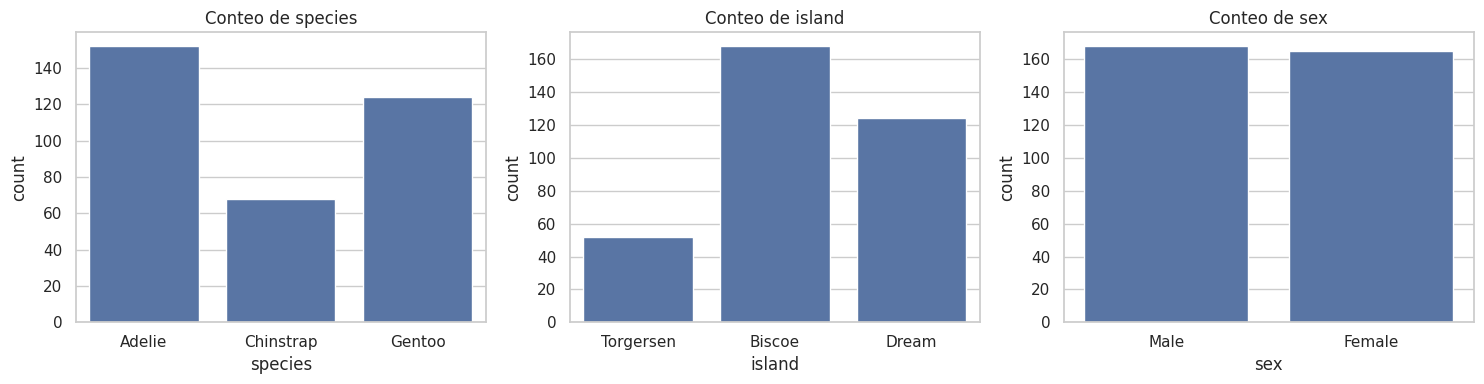

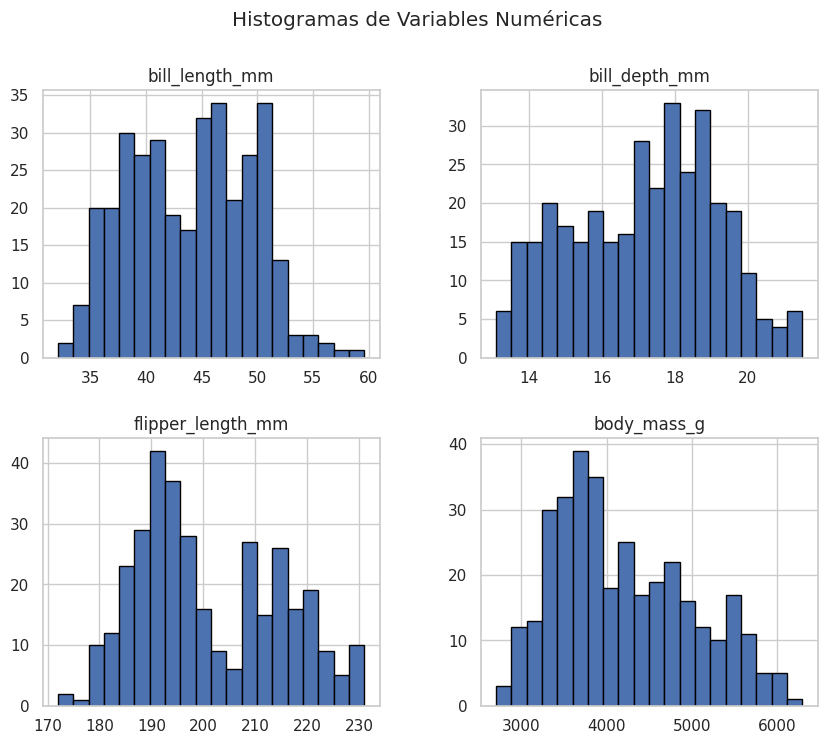

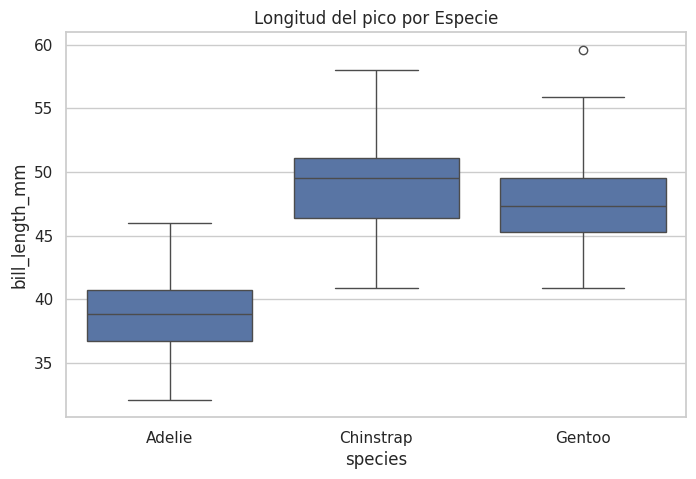

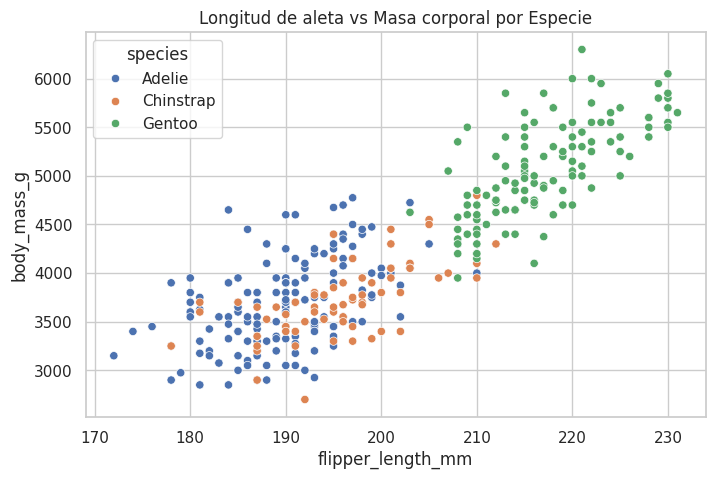

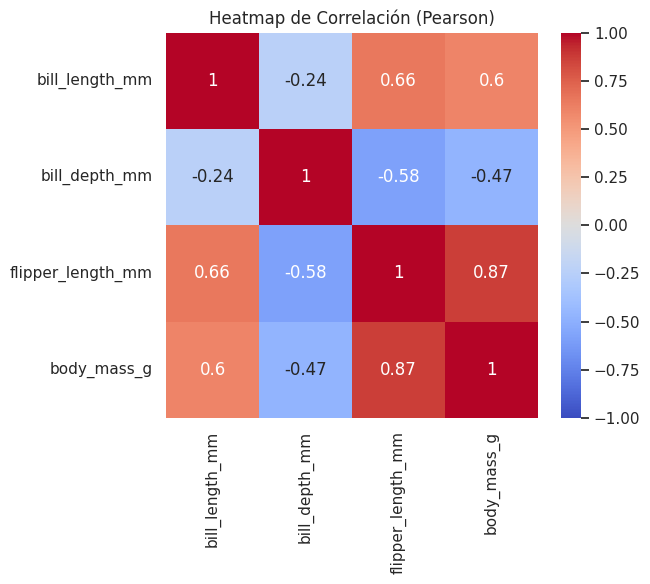

In [4]:
#Parte C
# Configuración visual
sns.set_theme(style="whitegrid")

# 10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
plt.figure(figsize=(15, 4))
for i, col in enumerate(baja_cardinalidad, 1):
    plt.subplot(1, len(baja_cardinalidad), i)
    sns.countplot(data=df, x=col)
    plt.title(f"Conteo de {col}")
plt.tight_layout()
plt.show()

# 11) Genere histogramas para variables numéricas y describa su forma.
df[num_vars].hist(bins=20, figsize=(10, 8), edgecolor='black')
plt.suptitle('Histogramas de Variables Numéricas')
plt.show()

# 12) Genere boxplots de una variable numérica por categoría (bill_length_mm por species).
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='species', y='bill_length_mm')
plt.title('Longitud del pico por Especie')
plt.show()

# 13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.title('Longitud de aleta vs Masa corporal por Especie')
plt.show()

# 14) Genere un heatmap de correlación.
plt.figure(figsize=(6, 5))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap de Correlación (Pearson)')
plt.show()

In [5]:
#Parte D y E
# Limpieza temporal de NaNs para poder hacer las pruebas estadísticas
df_clean = df.dropna()

# --- Hipótesis 1: La longitud de la aleta (flipper_length_mm) tiene correlación con la masa corporal (body_mass_g) ---
# Prueba: Correlación de Pearson
pearson_r, pearson_p = stats.pearsonr(df_clean['flipper_length_mm'], df_clean['body_mass_g'])
print(f"H1 - Correlación de Pearson: r = {pearson_r:.4f}, p-valor = {pearson_p:.4e}")
if pearson_p < 0.05:
    print("Evidencia apoya H1: Hay una asociación significativa.")
else:
    print("Evidencia no apoya H1.")

# --- Hipótesis 2: Existe una asociación entre la especie (species) y la isla (island) ---
# Prueba: Chicuadrado de independencia
contingency_table = pd.crosstab(df_clean['species'], df_clean['island'])
chi2, chi2_p, dof, ex = stats.chi2_contingency(contingency_table)
print(f"\nH3 - Prueba Chi-cuadrado: Chi2 = {chi2:.4f}, p-valor = {chi2_p:.4e}")
if chi2_p < 0.05:
    print("Evidencia apoya H3: Las especies y las islas no son independientes (están asociadas).")
else:
    print("Evidencia no apoya H3.")

H1 - Correlación de Pearson: r = 0.8730, p-valor = 3.1328e-105
Evidencia apoya H1: Hay una asociación significativa.

H2 - Prueba ANOVA: F = 397.2994, p-valor = 1.3810e-88
Evidencia apoya H2: Hay diferencias significativas en la longitud del pico entre especies.

H3 - Prueba Chi-cuadrado: Chi2 = 284.5900, p-valor = 2.2819e-60
Evidencia apoya H3: Las especies y las islas no son independientes (están asociadas).


Parte F
### Conclusiones
**A) Hallazgos descriptivos:**
- El dataset cuenta con 344 filas y 7 columnas (4 numéricas, 3 categóricas).
- Faltan 2 valores para las variables del pico y aleta, y 11 para la variable sexo. No existen registros duplicados exactos.
- La especie predominante es Adelie (44.2%), seguida de Gentoo (35.9%).

**B) Patrones visuales:**
- Se observa una correlación positiva y fuerte (r = 0.87) entre la longitud de la aleta (`flipper_length_mm`) y la masa corporal (`body_mass_g`), claramente distinguible en el scatter plot.
- El boxplot demuestra que la especie Gentoo tiene en promedio valores mucho más altos para variables como el tamaño del pico o masa corporal.

**C) Próximas hipótesis a probar:**
- La profundidad del pico (`bill_depth_mm`) difiere significativamente entre machos y hembras controlando por la especie.